In [70]:
import os

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import hashlib

from torch_geometric.data import Data, Dataset as PyGDataset

from qqe.GNN.physics_aware_NN import GNN, QuantumCircuitGraphDataset
import torch.nn as nn
from torch_geometric.loader import DataLoader

In [71]:
from qqe.GNN.training.utils import collect_files_path, cache_root_paths

In [72]:
def _plot_SRE_distribution(
    dataset,
    bins=30,
    value_range=None,
    density=True,
    show_mean=True,
    min_count=1,
    title="SRE frequency by number of qubits",
):
    grouped_sre = {}

    # -----------------------------
    # Collect SRE values by qubit count
    # -----------------------------
    for data in dataset:
        if not hasattr(data, "num_qubits"):
            continue
        if not hasattr(data, "y") or data.y is None:
            continue

        q = int(data.num_qubits)

        # robust extraction of scalar y
        y = data.y
        if torch.is_tensor(y):
            if y.numel() == 0:
                continue
            y_val = float(y.view(-1)[0].item())
        else:
            y_val = float(np.array(y).reshape(-1)[0])

        if not np.isfinite(y_val):
            continue

        grouped_sre.setdefault(q, []).append(y_val)

    # remove groups with too few points
    grouped_sre = {q: vals for q, vals in grouped_sre.items() if len(vals) >= min_count}

    if not grouped_sre:
        raise ValueError("No valid finite SRE values found in the dataset.")

    # -----------------------------
    # Determine histogram range
    # -----------------------------
    all_vals = np.concatenate([np.asarray(v, dtype=float) for v in grouped_sre.values()])
    if value_range is None:
        xmin = float(np.nanmin(all_vals))
        xmax = float(np.nanmax(all_vals))
        if xmin == xmax:
            xmin -= 0.5
            xmax += 0.5
        value_range = (xmin, xmax)

    bin_edges = np.linspace(value_range[0], value_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(9, 6))

    for q in sorted(grouped_sre):
        vals = np.array(grouped_sre[q])

        counts, _ = np.histogram(vals, bins=bin_edges)

        if density:
            freq = 100 * counts / counts.sum()
        else:
            freq = counts

        # plot curve and capture color
        line, = plt.plot(bin_centers, freq, label=f"{q} qubits")
        color = line.get_color()

        # plot mean with SAME color
        if show_mean:
            mean_val = vals.mean()
            plt.axvline(
                mean_val,
                linestyle="--",
                linewidth=1.5,
                color=color,
                alpha=0.9,
            )

            ymax = freq.max()
            plt.text(
                mean_val - 0.5,
                ymax + 0.5,
                f"{mean_val:.2f}",
                color=color,
                ha="center",
                fontsize=8,
            )

    plt.xlabel("Stabilizer Rényi Entropy")
    plt.ylabel("Frequency (%)")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [98]:
global_feature_variant: str = "binned"
node_feature_variant: str | None = None
family_projection: str | None = None

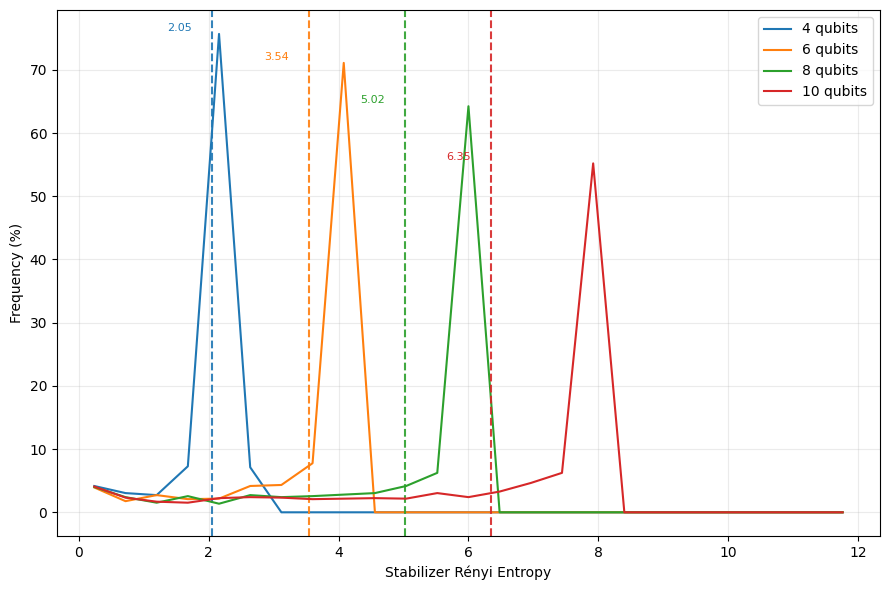

In [99]:
family = "clifford"
# family = None
dataset_paths = collect_files_path('../outputs/data', family=family)
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#clifford
_plot_SRE_distribution(
    base_dataset,
    bins=25,
    value_range=(0, 12),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)

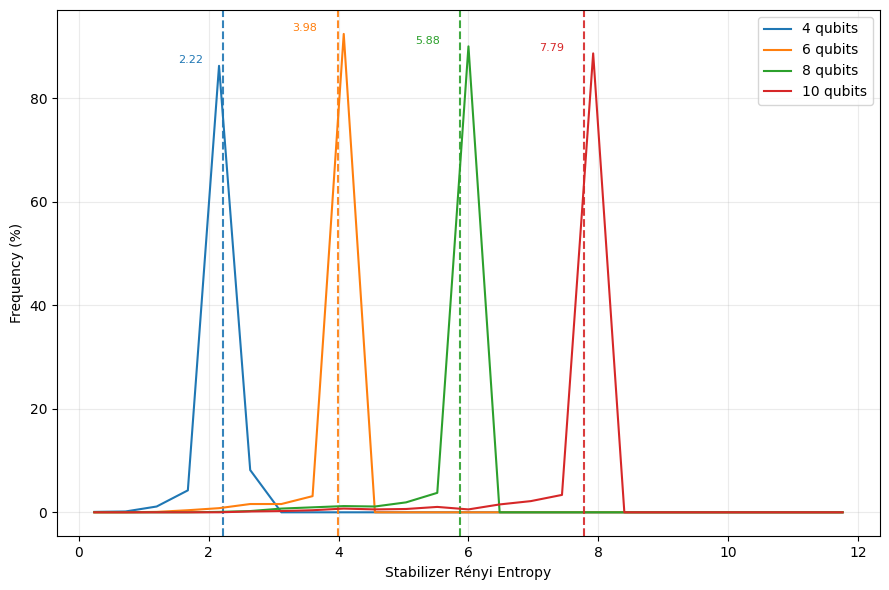

In [100]:
family = "quansistor"
# family = None
dataset_paths = collect_files_path('../outputs/data', family=family)
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#clifford
_plot_SRE_distribution(
    base_dataset,
    bins=25,
    value_range=(0, 12),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)

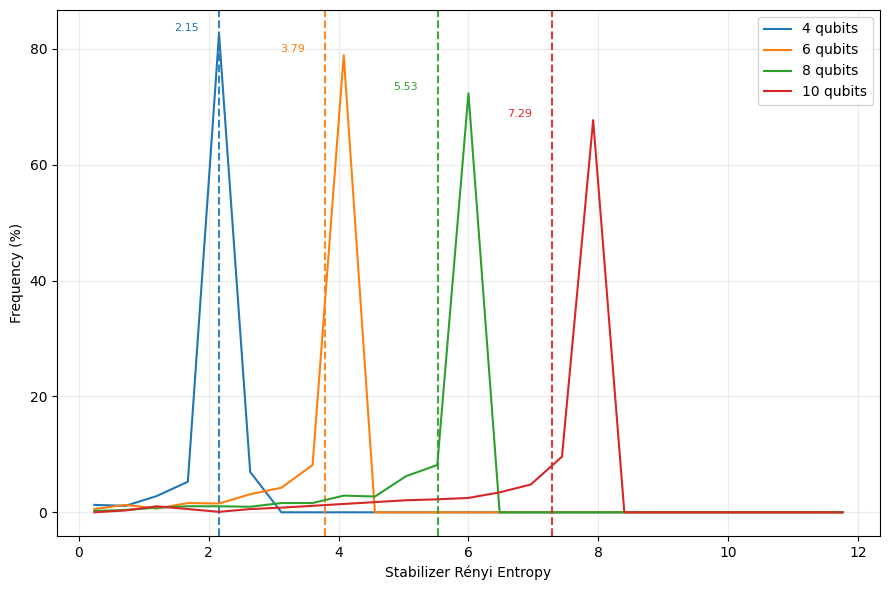

In [101]:
family = "random"
# family = None
dataset_paths = collect_files_path('../outputs/data', family=family)
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#clifford
_plot_SRE_distribution(
    base_dataset,
    bins=25,
    value_range=(0, 12),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)

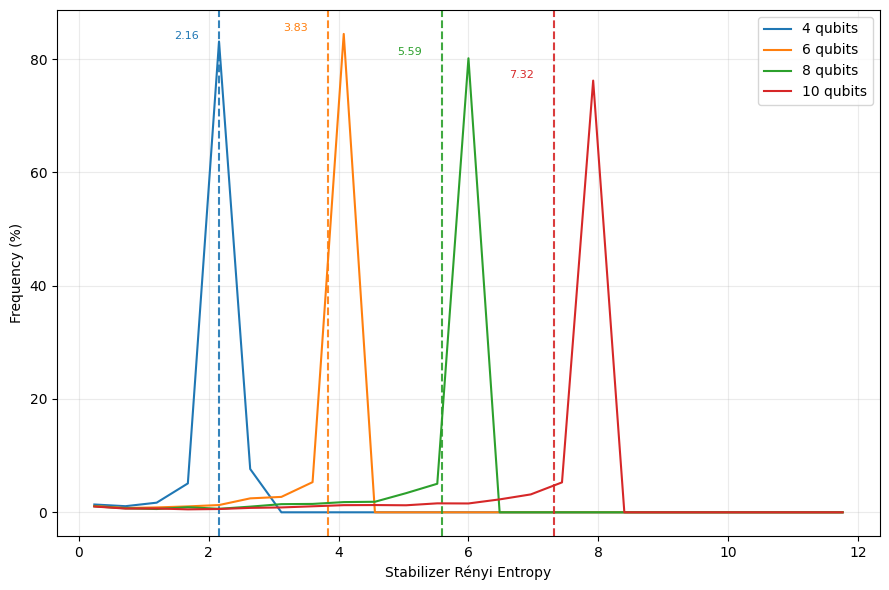

: 

In [ ]:
# family = "clifford"
family = None
dataset_paths = collect_files_path('../outputs/data', family=family)
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#clifford
_plot_SRE_distribution(
    base_dataset,
    bins=25,
    value_range=(0, 12),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)